<a href="https://colab.research.google.com/github/ranatushar7579/Project/blob/main/Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [55]:
# Load Dataset

df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [56]:
import pandas as pd

# Load original CSV
df = pd.read_csv("cardio_train.csv", sep=";")

# Convert age from days to years
df["age_years"] = (df["age"] / 365.25).round().astype(int)

# Save updated CSV
df.to_csv("cardio_train_with_age_years.csv", sep=";", index=False)

print("age_years column successfully added!")
print(df[["age", "age_years"]].head())

age_years column successfully added!
     age  age_years
0  18393         50
1  20228         55
2  18857         52
3  17623         48
4  17474         48


In [57]:
# Convert age from days to years
df["age_years"] = (df["age"] / 365.25).round().astype(int)

# Check the result
print(df[["age", "age_years"]].head(10))

     age  age_years
0  18393         50
1  20228         55
2  18857         52
3  17623         48
4  17474         48
5  21914         60
6  22113         61
7  22584         62
8  17668         48
9  19834         54


In [58]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Shape
(70000, 14)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
 13  age_years    70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB


In [59]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64


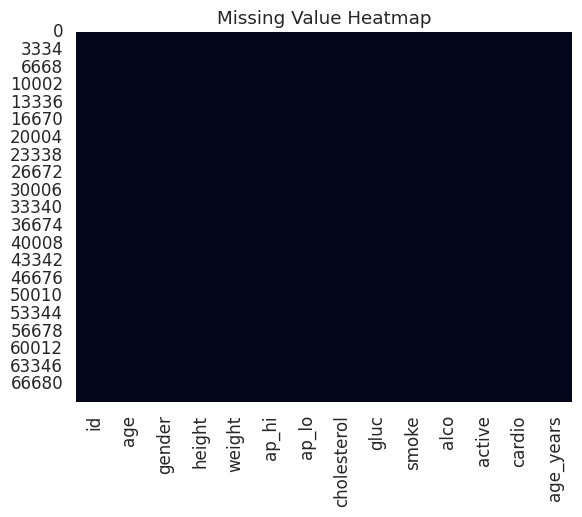

In [60]:
missing_values = df.isnull().sum()

print(missing_values)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [61]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)

Duplicate Records : 0
Shape After Removing Duplicates : (70000, 14)


In [62]:
# Remove ID column

if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years  
0     0       1       0         50  
1     0       1       1         55  
2     0       0       1         52  
3     0       1       1         48  
4     0       0       0         48  


In [63]:
# Statistical Summary

print("Statistical Summary")
print("=" * 50)

df.describe()

Statistical Summary


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.303157
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.760171
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [64]:
# Set Plot Style

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("EDA Started Successfully")

EDA Started Successfully


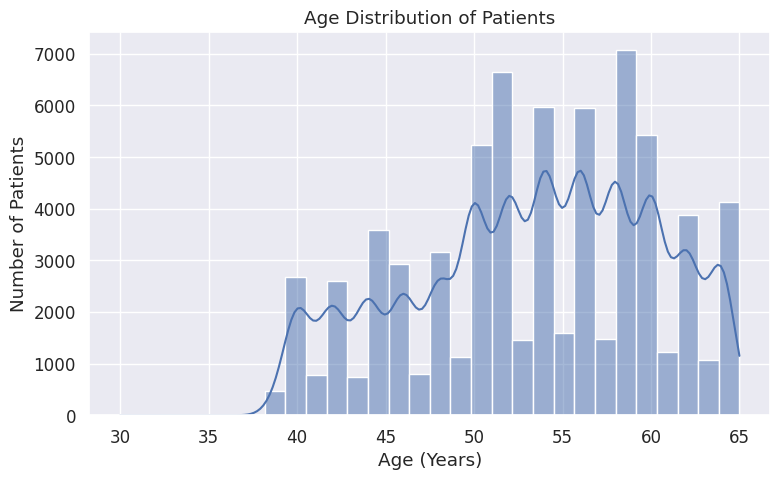

In [65]:
# Create age_years if it does not already exist

if "age_years" not in df.columns:
    df["age_years"] = (df["age"] / 365.25).astype(int)

# Univariate Analysis - Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age_years",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

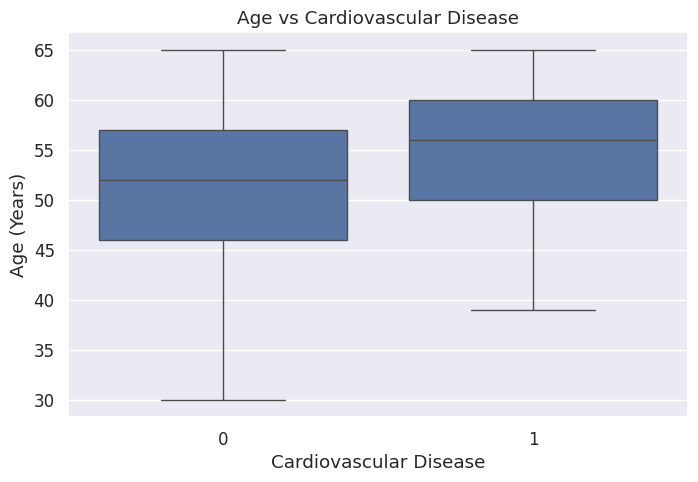

In [66]:
# Bivariate Analysis - Age vs Cardiovascular Disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cardio",
    y="age_years"
)

plt.title("Age vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")

plt.show()

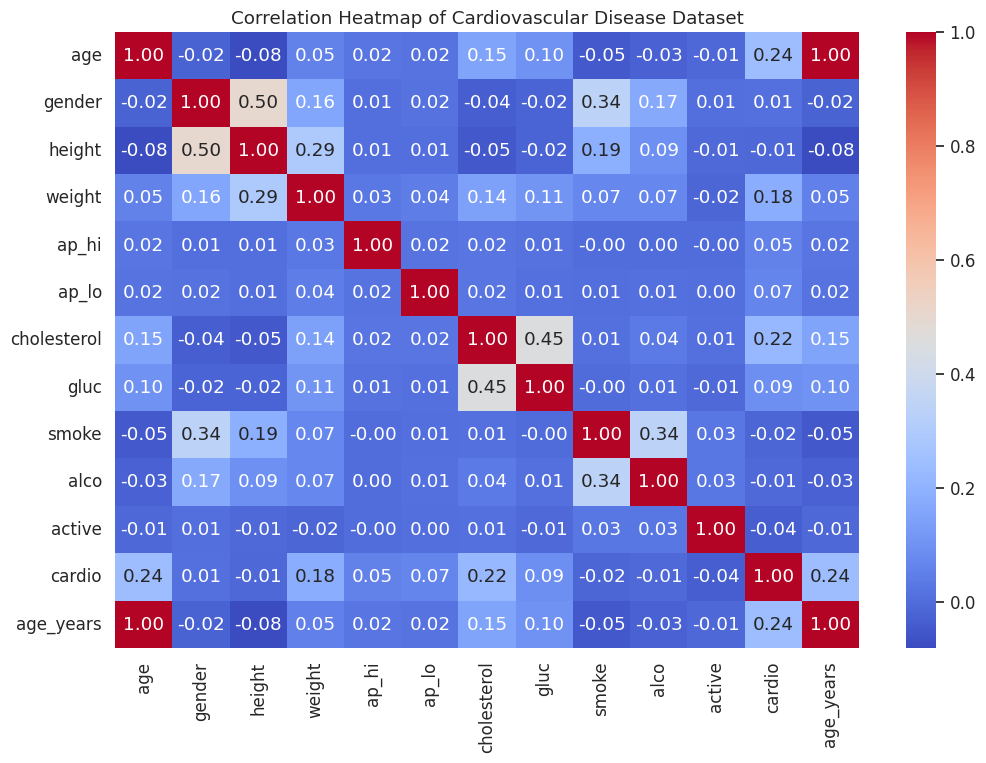

In [67]:
# Multivariate Analysis - Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Cardiovascular Disease Dataset")

plt.show()

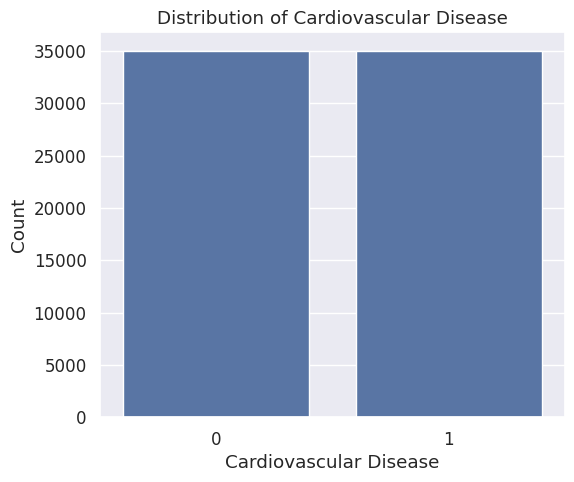

cardio
0    35021
1    34979
Name: count, dtype: int64


In [68]:
plt.figure(figsize=(6,5))

sns.countplot(x="cardio", data=df)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Count")

plt.show()

print(df["cardio"].value_counts())

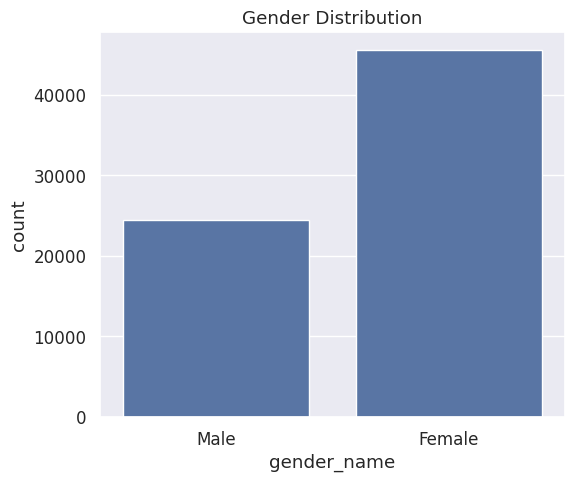

In [69]:
gender_map = {1: "Female", 2: "Male"}

df["gender_name"] = df["gender"].map(gender_map)

plt.figure(figsize=(6,5))

sns.countplot(x="gender_name", data=df)

plt.title("Gender Distribution")

plt.show()

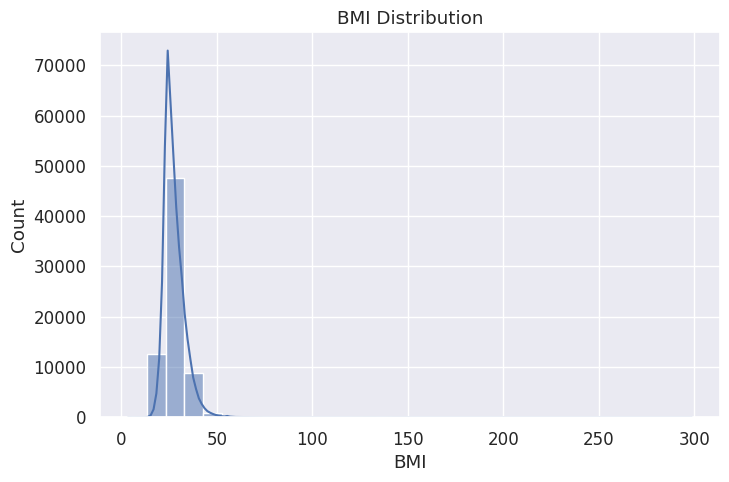

In [70]:
df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

plt.figure(figsize=(8,5))

sns.histplot(df["BMI"], bins=30, kde=True)

plt.title("BMI Distribution")

plt.show()

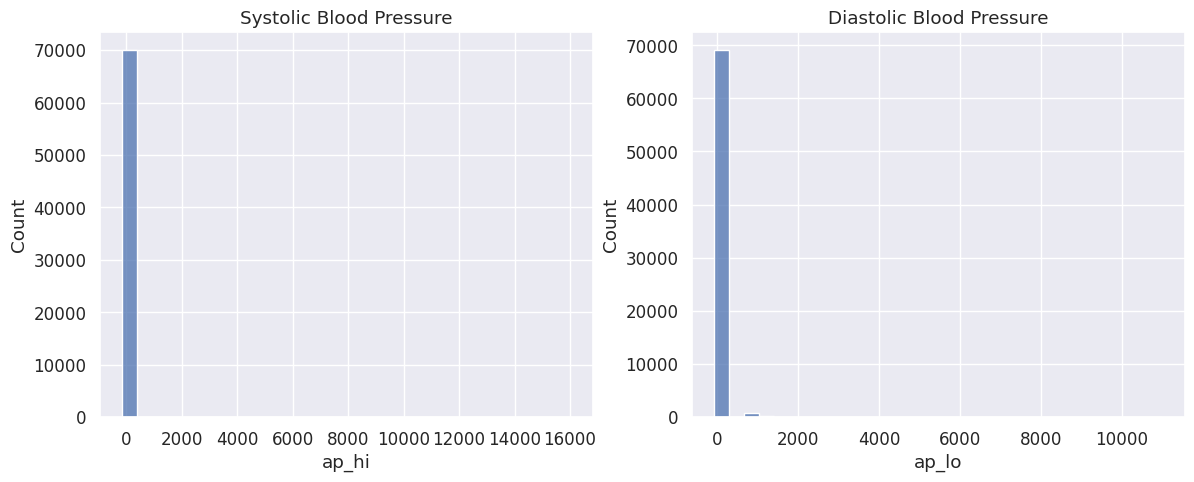

In [71]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df["ap_hi"], ax=ax[0], bins=30)

ax[0].set_title("Systolic Blood Pressure")

sns.histplot(df["ap_lo"], ax=ax[1], bins=30)

ax[1].set_title("Diastolic Blood Pressure")

plt.show()

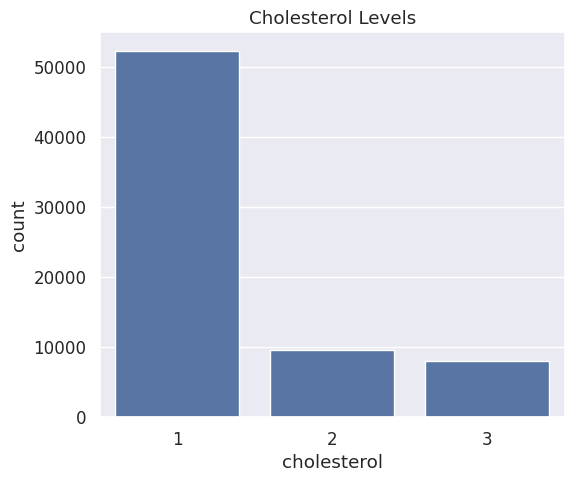

In [72]:
plt.figure(figsize=(6,5))

sns.countplot(x="cholesterol", data=df)

plt.title("Cholesterol Levels")

plt.show()

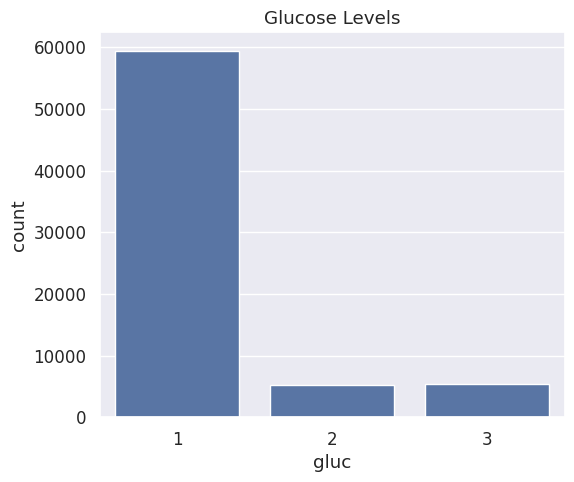

In [73]:
plt.figure(figsize=(6,5))

sns.countplot(x="gluc", data=df)

plt.title("Glucose Levels")

plt.show()

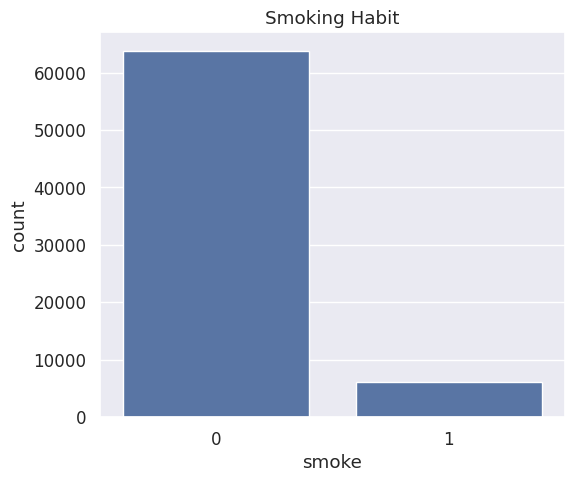

In [74]:
plt.figure(figsize=(6,5))

sns.countplot(x="smoke", data=df)

plt.title("Smoking Habit")

plt.show()

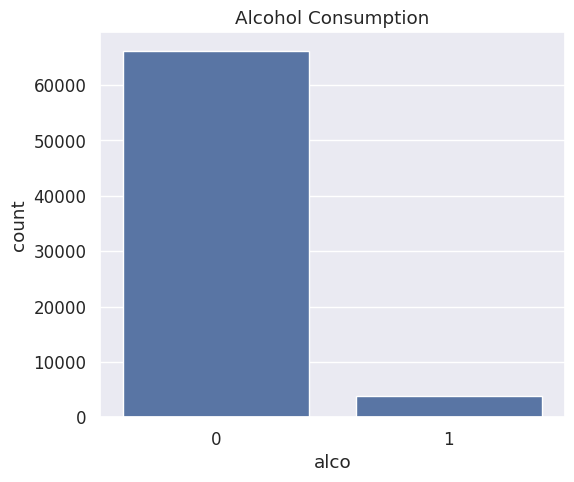

In [75]:
plt.figure(figsize=(6,5))

sns.countplot(x="alco", data=df)

plt.title("Alcohol Consumption")

plt.show()

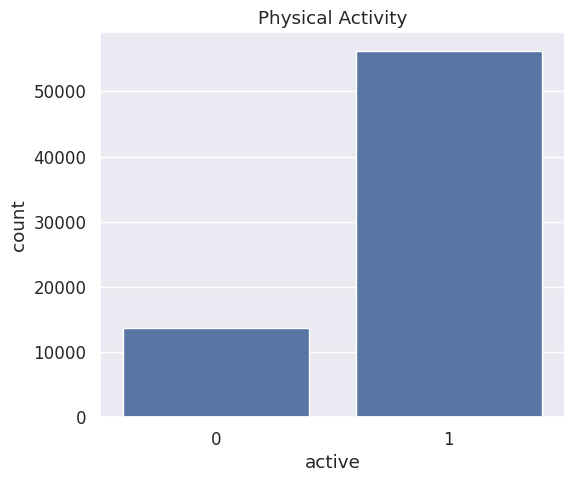

In [76]:
plt.figure(figsize=(6,5))

sns.countplot(x="active", data=df)

plt.title("Physical Activity")

plt.show()

In [77]:
# Create Age Feature (Years)

df["age_years"] = (df["age"] / 365.25).astype(int)

print(df[["age", "age_years"]].head())

     age  age_years
0  18393         50
1  20228         55
2  18857         51
3  17623         48
4  17474         47


In [78]:
# Create BMI Feature

df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

df[["height", "weight", "BMI"]].head()

,height,weight,BMI
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


In [79]:
# Remove Invalid Blood Pressure

df = df[df["ap_hi"] > 50]
df = df[df["ap_hi"] < 250]

df = df[df["ap_lo"] > 30]
df = df[df["ap_lo"] < 180]

df = df[df["ap_hi"] > df["ap_lo"]]

print("Dataset Shape:", df.shape)

Dataset Shape: (68670, 16)


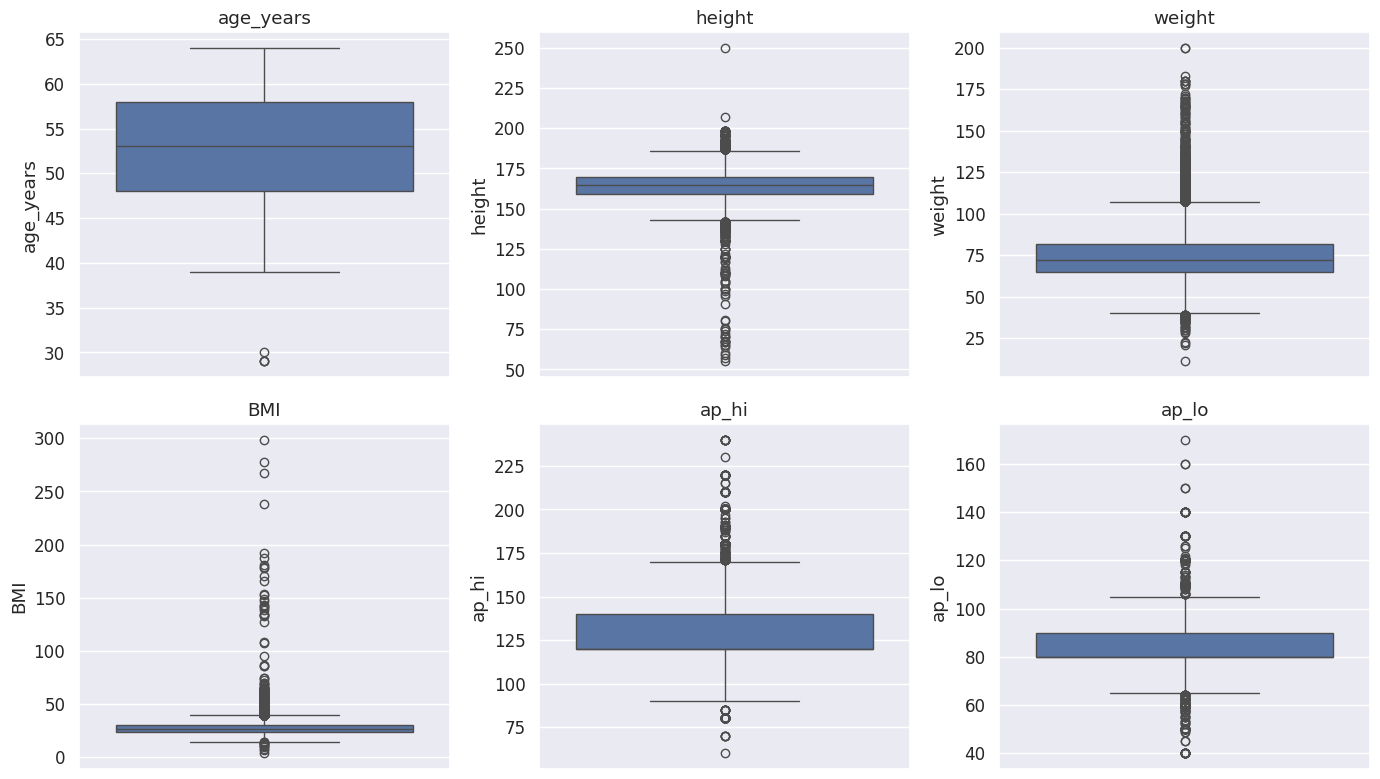

In [80]:
numerical_columns = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo"
]

plt.figure(figsize=(14,8))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [81]:
df = df[(df["BMI"] > 10) & (df["BMI"] < 60)]

print(df.shape)

(68603, 16)


In [82]:
X = df.drop(columns=["cardio"])

y = df["cardio"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (68603, 15)
Target Shape : (68603,)


In [83]:
# Remove non-numeric columns created for visualization

columns_to_drop = ["gender_name", "height_m"]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Features and Target
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Check data types
print(X.dtypes)

age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
age_years        int64
BMI            float64
dtype: object


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (54882, 13)
Testing Data : (13721, 13)


In [85]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (54882, 13)
X_test shape : (13721, 13)
y_train shape: (54882,)
y_test shape : (13721,)


In [86]:
# Features and Target

X = df.drop("cardio", axis=1)
y = df["cardio"]

print("Total Records:", len(df))
print("Total Features:", X.shape[1])
print("Features:")
print(X.columns.tolist())

Total Records: 68603
Total Features: 13
Features:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'BMI']


In [87]:
#Training and Testing Data Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

print("\nTraining Target:", y_train.shape)
print("Testing Target :", y_test.shape)

Training Data: (54882, 13)
Testing Data : (13721, 13)

Training Target: (54882,)
Testing Target : (13721,)


In [88]:
# Exact Number

print("=" * 50)
print("DATA SPLIT SUMMARY")
print("=" * 50)

print("Total Dataset Records :", len(df))
print("Training Records      :", len(X_train))
print("Testing Records       :", len(X_test))

print("\nTraining Percentage:", round(len(X_train) / len(df) * 100, 2), "%")
print("Testing Percentage :", round(len(X_test) / len(df) * 100, 2), "%")

DATA SPLIT SUMMARY
Total Dataset Records : 68603
Training Records      : 54882
Testing Records       : 13721

Training Percentage: 80.0 %
Testing Percentage : 20.0 %


In [89]:
# Create Training Dataset

train_data = X_train.copy()
train_data["cardio"] = y_train.values

train_data.to_csv(
    "cardiovascular_training_data.csv",
    index=False
)

print("Training CSV created successfully!")

Training CSV created successfully!


In [90]:
# Create Testing Dataset

test_data = X_test.copy()
test_data["cardio"] = y_test.values

test_data.to_csv(
    "cardiovascular_testing_data.csv",
    index=False
)

print("Testing CSV created successfully!")

Testing CSV created successfully!


In [91]:
#Verify two files
print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape :", test_data.shape)

print("\nTraining Dataset:")
display(train_data.head())

print("\nTesting Dataset:")
display(test_data.head())

Training Dataset Shape: (54882, 14)
Testing Dataset Shape : (13721, 14)

Training Dataset:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,BMI,cardio
23358,20293,1,164,64.0,120,80,1,1,0,0,0,55,23.795360,0
30712,16903,1,155,67.0,150,100,2,2,0,0,1,46,27.887617,1
59790,15488,2,171,71.0,105,70,1,1,0,1,1,42,24.280975,0
50483,19624,1,163,77.0,110,90,2,1,0,0,1,53,28.981143,1
28064,19615,1,170,105.0,130,80,3,3,0,0,1,53,36.332180,1



Testing Dataset:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,BMI,cardio
60039,16536,2,170,68.0,120,80,3,3,0,0,1,45,23.529412,0
39377,23440,2,164,84.0,120,60,1,1,0,0,0,64,31.231410,1
29899,18925,1,165,97.0,140,90,1,1,0,0,0,51,35.629017,1
39323,21288,2,168,60.0,120,80,1,1,0,0,1,58,21.258503,0
22330,18871,1,164,80.0,110,70,2,1,0,0,1,51,29.744200,0


In [92]:
#Training/Test Target Distribution

print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Target Distribution:
cardio
0    27731
1    27151
Name: count, dtype: int64

Testing Target Distribution:
cardio
0    6933
1    6788
Name: count, dtype: int64


In [93]:
#Show percentage
#This shows that because of stratify=y, the distribution of cardio=0 and cardio=1 is kept balanced in both the training and testing datasets.

print("Training Target Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Target Percentage:
cardio
0    50.53
1    49.47
Name: proportion, dtype: float64

Testing Target Percentage:
cardio
0    50.53
1    49.47
Name: proportion, dtype: float64


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform test data using training parameters
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [95]:
#P-4
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression

In [96]:
# Create Empty Dictionary

model_results = {}

In [97]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

model_results["Logistic Regression"] = {

    "Accuracy": accuracy_score(y_test, lr_pred),

    "Precision": precision_score(y_test, lr_pred),

    "Recall": recall_score(y_test, lr_pred),

    "F1 Score": f1_score(y_test, lr_pred),

    "ROC AUC": roc_auc_score(y_test, lr_prob)

}

print(model_results["Logistic Regression"])

{'Accuracy': 0.7283725675971139, 'Precision': 0.7557226399331662, 'Recall': 0.6663229228049499, 'F1 Score': 0.708212636029124, 'ROC AUC': np.float64(0.7969465889567977)}


In [98]:
results_df = pd.DataFrame(model_results).T

results_df = results_df.round(4)

results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.7284,0.7557,0.6663,0.7082,0.7969


In [99]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
}

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_scores[name] = scores.mean()

    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.7265


In [100]:
cv_df = pd.DataFrame(
    list(cv_scores.items()),
    columns=["Model", "CV Accuracy"]
)

cv_df = cv_df.sort_values(
    "CV Accuracy",
    ascending=False
).reset_index(drop=True)

cv_df

,Model,CV Accuracy
0,Logistic Regression,0.726486


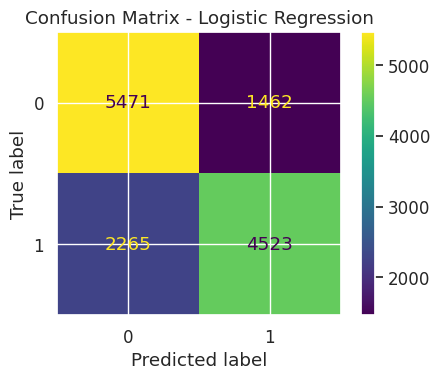

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    "Logistic Regression": lr_pred,
}

for name, pred in predictions.items():

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        ax=ax
    )

    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

In [102]:
# Create Final Model Comparison Table

final_results = pd.DataFrame(model_results).T

final_results = final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
]

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

final_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.7284,0.7557,0.6663,0.7082,0.7969


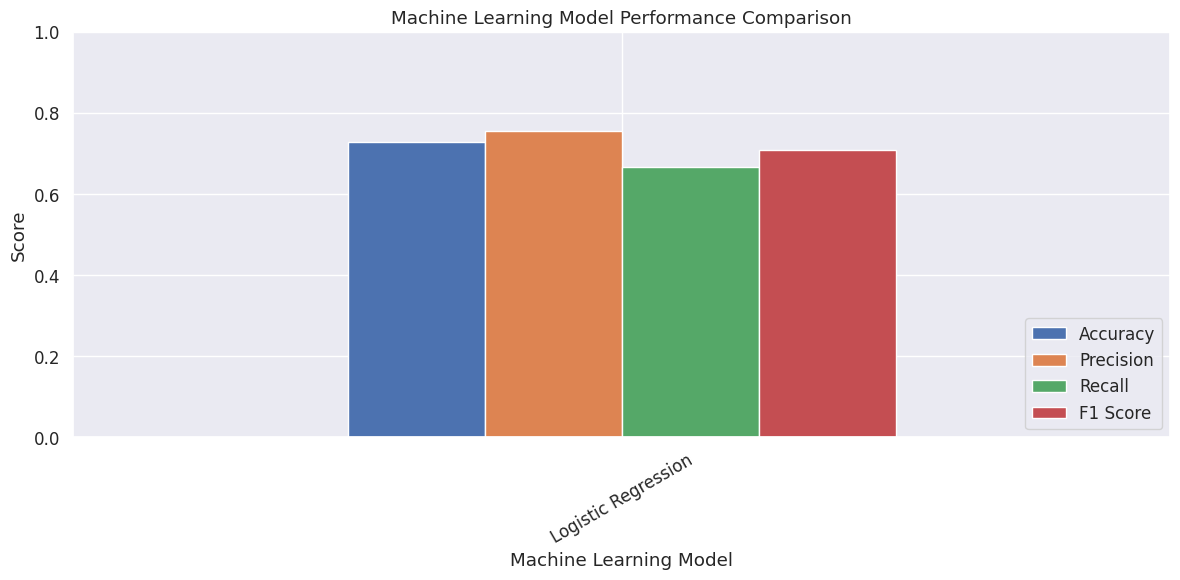

In [103]:
# Model Performance Comparison

final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()